In [58]:
from typing import Self

import numpy as np

import matplotlib.pyplot as plt

%matplotlib inline

In [34]:
ROWS = 4
COLS = 5

In [ ]:
# def fours(board, player: int) -> int:
#     counter = 0
#     nb = np.array(board == player, dtype=np.int_)

#     for r in range(ROWS):
#         for c in range(COLS):
#             if nb[r, c] == player:
#                 if r + 3 < ROWS and sum([nb[r + i, c] for i in range(4)]) == 4 * player:
#                     counter += 1
#                     for i in range(4):
#                         nb[r + i, c] = 0
#                 if c + 3 < COLS and sum([nb[r, c + i] for i in range(4)]) == 4 * player:
#                     counter += 1
#                     for i in range(4):
#                         nb[r, c + i] = 0
#                 if (
#                     r + 3 < ROWS
#                     and c + 3 < COLS
#                     and sum([nb[r + i, c + i] for i in range(4)]) == 4 * player
#                 ):
#                     counter += 1
#                     for i in range(4):
#                         nb[r + i, c + i] = 0
#                 if (
#                     0 <= r - 3
#                     and c + 3 < COLS
#                     and sum([nb[r - i, c + i] for i in range(4)]) == 4 * player
#                 ):
#                     counter += 1
#                     for i in range(4):
#                         nb[r - i, c + i] = 0
#     if counter == 0 and sum(nb) == ROWS *  COLS:
#         return 0
#     elif counter > 0:
#         return counter
#     else: 
#         return None

In [35]:
def has_four(board, player: int) -> bool:

    nb = np.array(board == player, dtype=np.int_)

    for r in range(ROWS):
        for c in range(COLS):
            if nb[r, c] == player:
                if r + 3 < ROWS and sum([nb[r + i, c] for i in range(4)]) == 4 * player:
                    return True
                if c + 3 < COLS and sum([nb[r, c + i] for i in range(4)]) == 4 * player:
                    return True
                if (
                    r + 3 < ROWS
                    and c + 3 < COLS
                    and sum([nb[r + i, c + i] for i in range(4)]) == 4 * player
                ):
                    return True
                if (
                    0 <= r - 3
                    and c + 3 < COLS
                    and sum([nb[r - i, c + i] for i in range(4)]) == 4 * player
                ):
                    return True
    return False

In [37]:
start = np.zeros(shape=(ROWS, COLS), dtype=np.int_)


class Board:
    def __init__(self, board: np.ndarray) -> None:

        assert board.shape == (ROWS, COLS)
        self.board = board

    @property
    def player(self) -> int:
        s = np.sum(self.board)
        if s == 0:
            return 1
        elif s == 1:
            return -1
        else:
            raise ValueError(f"not valid board sum {s}")
        
    @property
    def score(self) -> int:
        if has_four(self.board, player=1):
            return 10
        elif has_four(self.board, player=-1):
            return -10
        else:
            return 0

    @property
    def available_actions(self) -> list[int]:
        return [i for i in range(COLS) if self.board[-1, i] == 0]

    def go(self, col: int) -> None:
        assert col in self.available_actions, f"action {col=} not in {self.available_actions}"
        for i in range(ROWS):
            if self.board[i, col] == 0:
                self.board[i, col] = self.player
                break

    def new_board(self, col: int) -> np.ndarray:
        assert col in self.available_actions, f"action {col=} not in {self.available_actions}"
        board = self.board.copy()
        for i in range(ROWS):
            if board[i, col] == 0:
                board[i, col] = self.player
                break
        return board

    @property
    def final(self) -> bool:
        if len(self.available_actions) == 0:
            return True
        elif has_four(self.board, player=1) or has_four(self.board, player=-1):
            return True
        else:
            return False

    def draw(self) -> plt.Figure:
        fig = plt.Figure(figsize=(6, 4))
        ax = fig.gca()

        for c in range(COLS):
            for r in range(ROWS):
                fill = True
                color = "y"
                if self.board[r, c] == 1:
                    color = "b"
                elif self.board[r, c] == -1:
                    color = "r"
                else:
                    color = "y"
                    fill = False

                circle = plt.Circle((c + 0.5, r + 0.5), 0.4, color=color, fill=fill)
                ax.add_patch(circle)

        ax.set_aspect("equal")
        ax.axis("off")

        ax.set_xlim((0, COLS))
        ax.set_ylim((0, ROWS))

        return fig

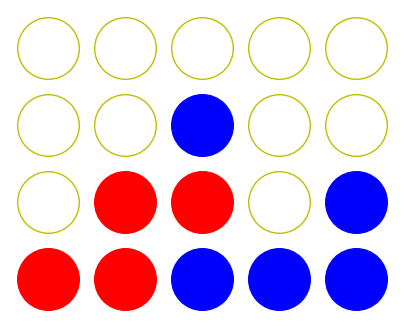

In [ ]:
class Node:
    def __init__(self, board: np.ndarray,  level: int, parent: Self | None = None):
        self.board = board
        self.level = level
        self.parent: Self | None = parent
        self.children: list[Node] = []


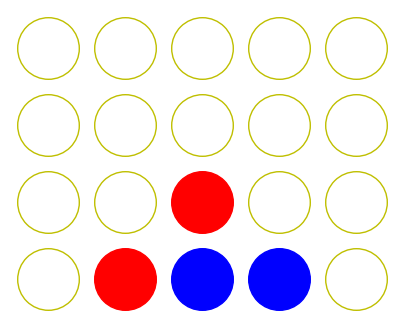

In [57]:
start = np.zeros(shape=(ROWS, COLS), dtype=np.int_)
board = Board(board=start)
board.go(2)
board.go(2)
board.go(3)
board.go(1)
# board.go(4)
# board.go(1)
# board.go(2)
# board.go(0)
# board.go(4)
# board.go(0)
# board.go(4)
# board.go(0)

fig = board.draw()
display(fig)

In [55]:
LEVEL = 5

root = Node(board=board.board, level=0)


def minimax(node: Node, prev_action: int| None = None) -> None:
    b = Board(board=node.board)
    if b.final or node.level >= LEVEL:
        return b.score, prev_action
    else:
        values = {}
        for action in b.available_actions:
            child = Node(
                board=b.new_board(col=action),
                level=node.level+1
            )
            child.parent = node
            values[action] = minimax(node=child, prev_action=action)[0]
        
        action, score = sorted(values.items(), key=lambda x: x[0], reverse=True if b.player==1 else False)[0]
        return score, action

minimax(node=root, prev_action=None)

(10, 4)

In [ ]:
LEVEL = 5

root = Node(board=board.board, level=0)


def minimax(node: Node, prev_action: int| None = None) -> None:
    b = Board(board=node.board)
    if b.final or node.level >= LEVEL:
        return b.score, prev_action
    else:
        value = -np.inf if b.player == 1 else np.inf
        actions = b.available_actions
        if len(actions) == 0:
            return b.score, prev_action
        else:
            pass

        if b.player == 1:
            value = -np.inf
        else:
            pass
        
        values = {}
        for action in b.available_actions:
            child = Node(
                board=b.new_board(col=action),
                level=node.level+1
            )
            child.parent = node
            values[action] = minimax(node=child, prev_action=action)[0]
        
        action, score = sorted(values.items(), key=lambda x: x[0], reverse=True if b.player==1 else False)[0]
        return score, action

minimax(node=root, prev_action=None)

In [29]:
d = {1:3, 4:5}
sorted(d.items(), key=lambda x: x[0], reverse=True)[0]

(4, 5)

In [ ]:
class MinMaxAlgorithm:

    def __init__(self, board: np.ndarray, state: int, depth: int, prev_action: int):
        self.board = board
        self.state = state # MIN: -1; MAX: 1
        self.depth = depth
        self.prev_action = prev_action

    def go(self) -> None:
        b = Board(board=self.board)
        if b.final or self.depth == 0:
            return b.score, self.prev_action
        else:
            reward = -np.inf if b.player == 1 else np.inf
            actions = b.available_actions
            if len(actions) == 0:
                pass # ???
            else:
                


        